# Venn (static)

> Area-proportional Euler/Venn diagram (2-3 sets) with itemised member labels, via [eunoia](https://github.com/jolars/eunoia).

In [1]:
#| default_exp venn

In [2]:
#| export
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.path import Path
from matplotlib.transforms import Bbox
import numpy as np
from scipy.ndimage import distance_transform_edt
import eunoia as eu
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

In [3]:
#| export
def _max_font_rect(mask, xs, ys, n_items, name_len, gutter):
    "Rectangle inside `mask` maximising the monospace font (over 1..8 columns) for `n_items` names of length `name_len`, then placed as centred as possible on the region's centroid; returns (cx, cy, width, height)."
    if not mask.any():
        return None
    H, W = mask.shape
    ii = np.zeros((H + 1, W + 1), np.int32)
    ii[1:, 1:] = mask.astype(np.int32).cumsum(0).cumsum(1)
    yi, xi = np.nonzero(mask)
    cy0, cx0 = yi.mean(), xi.mean()
    def block_sums(h, w):
        return ii[h:, w:] - ii[:-h, w:] - ii[h:, :-w] + ii[:-h, :-w]
    best = None  # (font, w, h)
    for c in range(1, min(8, n_items) + 1):
        nw = 0.6 * (name_len + gutter) * c
        nh = 1.2 * (-(-n_items // c))
        lo, hi = 0.0, min(W / nw, H / nh)
        found = None
        for _ in range(16):
            mid = (lo + hi) / 2
            w = max(1, int(round(mid * nw)))
            h = max(1, int(round(mid * nh)))
            if w <= W and h <= H and (block_sums(h, w) == h * w).any():
                found = (min(w / nw, h / nh), w, h)
                lo = mid
            else:
                hi = mid
        if found is not None and (best is None or found[0] > best[0]):
            best = found
    if best is None:
        return None
    _, w, h = best
    pos = np.argwhere(block_sums(h, w) == h * w)  # top-left of every position the box fits
    d = (pos[:, 0] + h / 2.0 - cy0) ** 2 + (pos[:, 1] + w / 2.0 - cx0) ** 2
    top, left = pos[int(d.argmin())]  # the fitting position closest to the region centroid
    right, bot = left + w - 1, top + h - 1
    return (xs[left] + xs[right]) / 2, (ys[top] + ys[bot]) / 2, xs[right] - xs[left], ys[bot] - ys[top]

def _center_rect(mask, xs, ys):
    "Box grown outward from the region's geometric centre (centroid; falls back to the deepest point if the centroid lands outside a non-convex region) until each side hits the boundary."
    if not mask.any():
        return None
    yi, xi = np.nonzero(mask)
    cy, cx = int(round(yi.mean())), int(round(xi.mean()))
    if not mask[cy, cx]:
        cy, cx = np.unravel_index(distance_transform_edt(mask).argmax(), mask.shape)
    h_dim, w_dim = mask.shape
    top = bot = cy
    left = right = cx
    grew = True
    while grew:
        grew = False
        if top > 0 and mask[top - 1, left:right + 1].all():
            top -= 1; grew = True
        if bot < h_dim - 1 and mask[bot + 1, left:right + 1].all():
            bot += 1; grew = True
        if left > 0 and mask[top:bot + 1, left - 1].all():
            left -= 1; grew = True
        if right < w_dim - 1 and mask[top:bot + 1, right + 1].all():
            right += 1; grew = True
    return (xs[left] + xs[right]) / 2, (ys[top] + ys[bot]) / 2, xs[right] - xs[left], ys[bot] - ys[top]

def _center(lbl, cnt, pole, ax, renderer, inv):
    "Stack the count above the member list, centred on `pole`; return the combined bbox in display coords."
    lbl.set_position(pole)
    cnt.set_position(pole)
    bi = lbl.get_window_extent(renderer)
    bc = cnt.get_window_extent(renderer)
    shift = (bi.height - bc.height) / 2
    px, py = ax.transData.transform(pole)
    pos = inv.transform((px, py + shift))
    lbl.set_position(pos)
    cnt.set_position(pos)
    b = Bbox.union([bi, bc])
    return Bbox.from_bounds(b.x0, b.y0 + shift, b.width, b.height)

def _block(items, cols, gutter):
    "Lay `items` into `cols` centred, space-padded columns and return the text block."
    rows = -(-len(items) // cols)
    col_items = [items[c * rows:(c + 1) * rows] for c in range(cols)]
    widths = [(max(len(i) for i in col) if col else 0) + gutter for col in col_items]
    return "\n".join("".join((col_items[c][r].center(widths[c]) if r < len(col_items[c]) else " " * widths[c])
                             for c in range(cols)) for r in range(rows))

def _outer_labels(outlines, labels, pad):
    "Position each set name just outside its shape, offset radially from the diagram centre."
    cents = {lab: np.asarray(outlines[lab]).mean(0) for lab in labels}
    C0 = np.concatenate([np.asarray(outlines[lab]) for lab in labels]).mean(0)
    out = {}
    for idx, lab in enumerate(labels):
        pts = np.asarray(outlines[lab])
        d = cents[lab] - C0
        if np.hypot(*d) < 1e-9:
            a = np.pi / 2 - idx * 2 * np.pi / len(labels)
            d = np.array([np.cos(a), np.sin(a)])
        d = d / np.hypot(*d)
        far = pts[(pts @ d).argmax()]
        pos = far + d * pad
        ha = "left" if d[0] > 0.3 else "right" if d[0] < -0.3 else "center"
        va = "bottom" if d[1] > 0.3 else "top" if d[1] < -0.3 else "center"
        out[lab] = (float(pos[0]), float(pos[1]), ha, va)
    return out

def eunoia_venn(dfs, colors, style="round", fontsize=None, inner_label_size=None, outer_label_size=None,
                title_size=None, font="Inter", fontcolor="black", count_color=None, title="",
                num_cols=None, gutter=2, margin=0.03, min_fontsize=6, max_fontsize=40,
                grid=380, seed=0, figsize=None, save_path=None):
    # style: "round" -> circle (2 sets) / ellipse (3 sets); "box" -> square (2 sets) / rectangle (3 sets)
    # colors: a list of colors, or the name of a matplotlib colormap (e.g. "Dark2")
    # For each region VISET grows a box outward from the region's deepest point until each side hits the
    # boundary, then fills it with the biggest font (searching over column counts) whose text block fits.
    # Because the box is wholly inside the region, the outline never crosses the text. `margin` is the
    # fraction kept clear inside that box.
    # num_cols: force a fixed column count; None (default) searches 1..8 columns and keeps the largest font.
    # seed: fixes eunoia's layout so the same data always draws the same diagram (eunoia is otherwise random).
    # font: title and set-label typeface only; member lists and counts stay monospace so their columns align.
    labels = [d.columns[0] for d in dfs]
    lists = [d.iloc[:, 0].tolist() for d in dfs]
    sets = [set(l) for l in lists]
    n = len(dfs)
    if isinstance(colors, str):
        cmap = plt.get_cmap(colors)
        pal = cmap.colors if hasattr(cmap, "colors") else [cmap(k / max(n - 1, 1)) for k in range(n)]
        colors = [pal[k % len(pal)] for k in range(n)]
    base = fontsize if fontsize is not None else 10
    inner = inner_label_size if inner_label_size is not None else base + 1
    outer = outer_label_size if outer_label_size is not None else inner + 2
    tsize = title_size if title_size is not None else outer + 1
    shape = {"round": "ellipse" if n == 3 else "circle", "box": "rectangle" if n == 3 else "square"}[style]
    member_font = ["IBM Plex Mono", "monospace"]  # inner text is locked to monospace so the padded columns align

    fig = plt.figure(figsize=figsize if figsize else ((12, 12) if n == 3 else (12, 10)))
    ax = plt.gca()
    fit = eu.euler({labels[i]: lists[i] for i in range(n)}, shape=shape, seed=seed)
    fit.plot(ax=ax, colors={labels[i]: colors[i] for i in range(n)}, labels=False, quantities=False, legend=False)
    outlines = fit.plot_data["shape_outlines"]
    allx = [p[0] for o in outlines.values() for p in o]
    ally = [p[1] for o in outlines.values() for p in o]
    span = max(max(allx) - min(allx), max(ally) - min(ally))
    m = 0.05 * span
    ax.set_xlim(min(allx) - m, max(allx) + m)
    ax.set_ylim(min(ally) - m, max(ally) + m)

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    inv = ax.transData.inverted()
    trans = ax.transData

    # rasterise every set once (in display space) on a square-celled grid; region masks are AND/NOT combinations
    disp = {lab: trans.transform(np.asarray(outlines[lab])) for lab in labels}
    allpx = np.concatenate(list(disp.values()))
    x0p, x1p = allpx[:, 0].min(), allpx[:, 0].max()
    y0p, y1p = allpx[:, 1].min(), allpx[:, 1].max()
    if (x1p - x0p) >= (y1p - y0p):
        gx = np.linspace(x0p, x1p, grid)
        step = gx[1] - gx[0]
        gy = np.linspace(y0p, y1p, max(2, int(round((y1p - y0p) / step)) + 1))
    else:
        gy = np.linspace(y0p, y1p, grid)
        step = gy[1] - gy[0]
        gx = np.linspace(x0p, x1p, max(2, int(round((x1p - x0p) / step)) + 1))
    GX, GY = np.meshgrid(gx, gy)
    P = np.column_stack([GX.ravel(), GY.ravel()])
    setmask = {lab: Path(disp[lab]).contains_points(P).reshape(len(gy), len(gx)) for lab in labels}

    for r in range(1, n + 1):
        for combo in combinations(range(n), r):
            s = set.intersection(*(sets[i] for i in combo)).difference(*(sets[i] for i in range(n) if i not in combo))
            if not s:
                continue
            items = [p for p in lists[combo[0]] if p in s]

            mask = np.ones((len(gy), len(gx)), bool)
            for i in combo:
                mask &= setmask[labels[i]]
            for j in range(n):
                if j not in combo:
                    mask &= ~setmask[labels[j]]
            if shape in ("ellipse", "circle"):  # curved regions: pick the widest-font box (centred grow gets pinched by the curve)
                rect = _max_font_rect(mask, gx, gy, len(items), max(len(x) for x in items), gutter)
            else:  # rectangular regions: grow outward from the geometric centre (fills the region and stays centred)
                rect = _center_rect(mask, gx, gy)
            if rect is None:
                continue
            cx, cy, box_w, box_h = rect
            avail_w = box_w * (1 - margin)
            avail_h = box_h * (1 - margin)
            pole = inv.transform((cx, cy))

            lbl = ax.text(0, 0, "", color=fontcolor, fontfamily=member_font, ha="center", va="top")
            if count_color is not None:
                cc = count_color
            else:
                parts = [mpl.colors.to_rgb(colors[i]) for i in combo]
                cc = [sum(ch) / len(parts) * 0.6 for ch in zip(*parts)]
            cnt = ax.text(0, 0, str(len(s)), ha="center", va="bottom", fontfamily=member_font, fontweight="semibold", color=cc)

            def place(cols, fs):
                lbl.set_text(_block(items, cols, gutter))
                lbl.set_fontsize(fs)
                cnt.set_fontsize(inner if fontsize is not None else fs + 1)
                return _center(lbl, cnt, pole, ax, renderer, inv)

            def fits(b):
                return b.width <= avail_w and b.height <= avail_h

            if fontsize is not None:
                place(min(num_cols, len(items)) if num_cols else (min(2, len(items)) if r == 1 else 1), fontsize)
                continue

            cand = [min(num_cols, len(items))] if num_cols else range(1, min(len(items), 8) + 1)
            best = None
            for cols in cand:
                lo, hi, fitfs = min_fontsize, max_fontsize, None
                while lo <= hi:  # largest font that fits (binary search; fits() is monotone in size)
                    mid = (lo + hi) // 2
                    if fits(place(cols, mid)):
                        fitfs = mid; lo = mid + 1
                    else:
                        hi = mid - 1
                if fitfs is not None:
                    if best is None or fitfs > best[0]:
                        best = (fitfs, cols)
                    elif best is not None and fitfs < best[0]:
                        break
            if best is None:
                # nothing fits at min_fontsize; use the column count whose min-font block overflows least
                ratios = []
                for c in cand:
                    b = place(c, min_fontsize)
                    ratios.append((max(b.width / avail_w, b.height / avail_h), c))
                place(min(ratios)[1], min_fontsize)
            else:
                place(best[1], best[0])

    positions = _outer_labels(outlines, labels, 0.02 * span)
    for idx, lab in enumerate(labels):
        x, y, ha, va = positions[lab]
        ax.text(x, y, lab, ha=ha, va=va, color=colors[idx], fontweight="semibold",
                fontsize=outer, fontfamily=font, clip_on=False)

    if title:
        plt.title(title, fontsize=tsize, fontweight="bold", color=fontcolor, fontfamily=font)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [4]:
#| hide
from viset.core import load
from matplotlib import font_manager
import matplotlib.pyplot as plt
for f in font_manager.findSystemFonts(fontpaths=["Font" if __import__("os").path.isdir("Font") else "../Font"]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

## Data

In [5]:
drugbase = ("Drug target sample files/" if __import__("os").path.isdir("Drug target sample files") else "../Drug target sample files/")
flu = load(drugbase + "1. FLUOXETINE_sample.csv", "Gene names", "Fluoxetine")
ibu = load(drugbase + "2. IBUPROFEN_sample.csv", "Gene names", "Ibuprofen")
acet = load(drugbase + "3. ACETAMINOPHEN_sample.csv", "Gene names", "Acetaminophen")

## Static Venn / Euler

Round style (circle for 2 sets, ellipse for 3), members auto-fit inside each region.

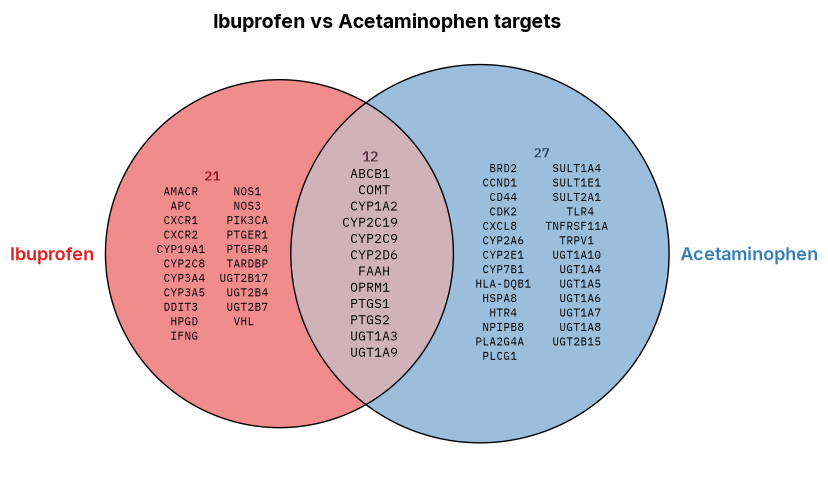

In [6]:
eunoia_venn([ibu, acet], colors="Set1", figsize=(8, 6.5), title="Ibuprofen vs Acetaminophen targets")

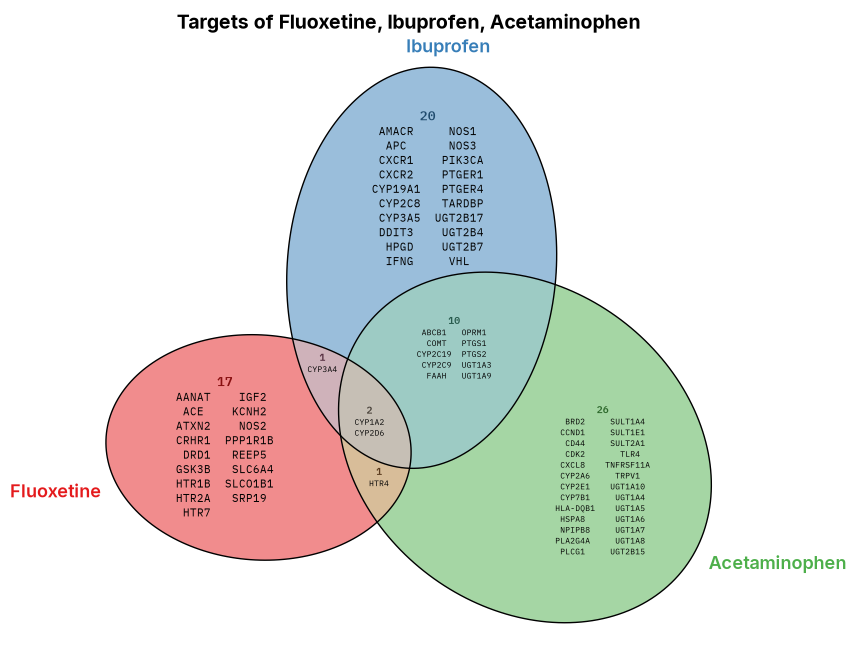

In [7]:
eunoia_venn([flu, ibu, acet], colors="Set1", figsize=(9, 8), title="Targets of Fluoxetine, Ibuprofen, Acetaminophen")

In [8]:

import sys, viset.venn as v, inspect
print(sys.executable)
print(v.__file__)
print("has fix:", "closest to the region centroid" in inspect.getsource(v._max_font_rect))

C:\Users\user\anaconda3\envs\viset\python.exe
C:\Users\user\Documents\GitHub\VISET\viset\venn.py
has fix: True


VISET also has a **box** style (`style="box"` — squares for two sets, rectangles for three). As the [Introduction](index.html) explains, rectangles *can* make all seven regions of a three-set diagram exactly area-proportional, but eunoia packs them tightly, so the itemised member lists have little room and read poorly. The **round** (ellipse) style shown above is recommended whenever you want the member names inside the regions; use `style="box"` mainly for the area-exact shapes themselves.

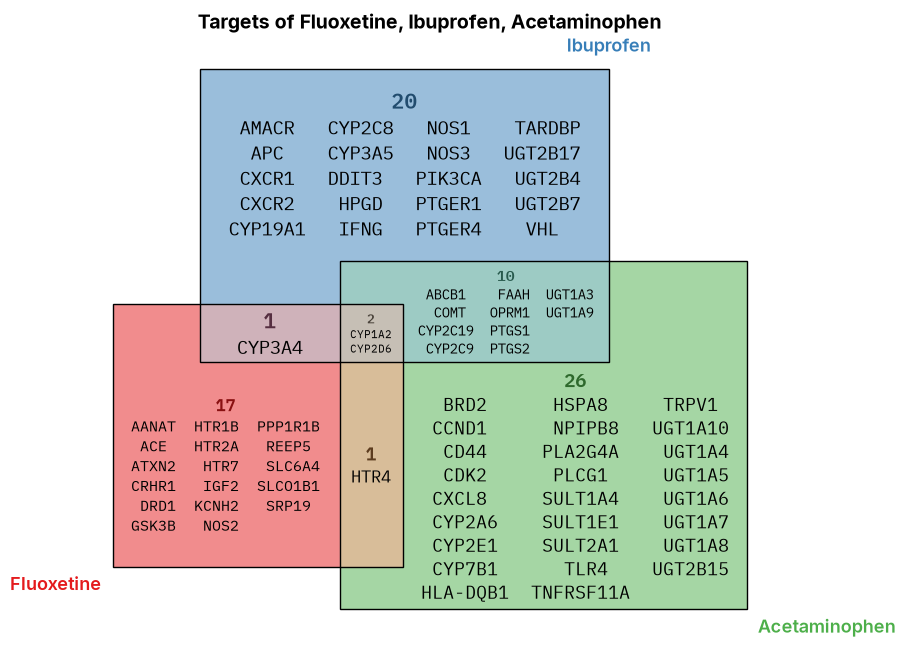

In [9]:
eunoia_venn([flu, ibu, acet], colors="Set1", figsize=(9, 8), style = "box", title="Targets of Fluoxetine, Ibuprofen, Acetaminophen")

## Controlling plot aesthetics

| Argument | Controls |
|---|---|
| `style` | `"round"` (circle for 2 sets, ellipse for 3) or `"box"` (square / rectangle) |
| `colors` | list of colours, or a Matplotlib colormap name (e.g. `"Set1"`, `"Dark2"`) |
| `title`, `title_size` | figure title text and size |
| `count_color` | colour of the intersection **count** numbers (default: a darkened blend of the region's set colours) |
| `fontcolor` | colour of the member-name text |
| `outer_label_size` | font size of the **set names** placed outside each shape |
| `num_cols` | force a fixed number of member columns per region (default: chosen automatically) |
| `fontsize` | force a fixed member font (default: auto-fit per region) |
| `min_fontsize`, `max_fontsize` | bounds for the automatic font search (defaults 6 and 40) |
| `gutter` | blank spaces between member columns |
| `margin` | fraction of the fitted box kept clear, so the outline never touches the text |
| `figsize`, `save_path` | figure size, and an optional path to save a 300-dpi PNG |

**Colormap names.** Any Matplotlib colormap name works for `colors`; qualitative maps keep the sets/bars most distinct: `Set1`, `Set2`, `Set3`, `Dark2`, `Paired`, `Accent`, `Pastel1`, `Pastel2`, `tab10`, `tab20`. You can also pass an explicit list of colours instead.